In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import scipy.optimize as opt
from scipy.special import gammaln
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.base.model import GenericLikelihoodModel
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')


In [2]:
# Load and clean data
data = pd.read_excel("/Users/kate/Downloads/data_sns_circles_June2024.xlsx", 
                     sheet_name="RI estimation testing June")

# Rename 'circle_number' to 'states'
data.rename(columns={'circle_number': 'states'}, inplace=True)

# Create a unique ID for each participant
data['ID'] = data.groupby('participant').ngroup() + 1

# Arrange data by ID and trial
data.sort_values(['ID', 'trial'], inplace=True)

In [3]:
# Summarize action counts
count_action = (data[['ID', 'states', 'engage', 'nengage']]
                .groupby(['ID', 'states'], as_index=False)
                .agg(sum_e=('engage', 'sum'), sum_n=('nengage', 'sum'))
                .sort_values(['ID', 'states']))

# Number of subjects and states
nsubj = data['participant'].nunique()
N = data['states'].nunique()


In [4]:
# Create engage and nengage matrices
engage = count_action.pivot(index='ID', columns='states', values='sum_e').fillna(0).values
nengage = count_action.pivot(index='ID', columns='states', values='sum_n').fillna(0).values

# Total trials per participant
ntrials = engage.sum(axis=1) + nengage.sum(axis=1)


In [5]:
# Multinomial function using gammaln for numerical stability
def multinom(x1, x2):
    return gammaln(x1 + x2 + 1) - (gammaln(x1 + 1) + gammaln(x2 + 1))


In [6]:
# Cost functions
def cost_llr(prob, k):
    summ = 0
    for i in range(N):
        for j in range(N):
            if i != j:
                term = (prob[i] * np.log(prob[i] / prob[j]) + 
                        (1 - prob[i]) * np.log((1 - prob[i]) / (1 - prob[j])))
                summ += (k / abs(i - j)**2) * term
    return summ

def cost_nh(prob, k):
    summ = 0
    for i in range(N - 1):
        p_sum = prob[i] + prob[i + 1]
        one_p_sum = 2 - prob[i] - prob[i + 1]
        summ += (prob[i] * np.log(prob[i] / p_sum) +
                 prob[i + 1] * np.log(prob[i + 1] / p_sum) +
                 (1 - prob[i]) * np.log((1 - prob[i]) / one_p_sum) +
                 (1 - prob[i + 1]) * np.log((1 - prob[i + 1]) / one_p_sum))
    return k * summ / N

def cost_mi(prob, k):
    prob_sum = np.sum(prob)
    one_prob_sum = N - prob_sum
    summ = np.sum((prob / N) * np.log(prob / prob_sum) +
                  ((1 - prob) / N) * np.log((1 - prob) / one_prob_sum))
    return k * summ

# Mapping model names to cost functions
cost_functions = {
    'LLR': cost_llr,
    'NH': cost_nh,
    'MI': cost_mi
}


In [7]:
# Define incentive structure and constraints
r = np.array([0, -0.5, -1, 1, 0.5, 0])
con_bounds = [(1e-6, 0.9999) for _ in range(N)]


In [8]:
# Grid search parameters
params = {
    'LLR': np.arange(0.001, 5.01, 0.01),
    'NH': np.arange(0.1, 20.1, 0.1),
    'MI': np.arange(0.1, 20.1, 0.1)
}


In [9]:
# Initialize dictionaries to store results
initvals = {'LLR': np.zeros(nsubj), 'NH': np.zeros(nsubj), 'MI': np.zeros(nsubj)}

# Adjust the initial guess for optimization to match the R code
initial_guess = np.full(N, 1 / 20)  # Initial guess of 1/20 for each state

# Function to compute multinomial constant
def compute_multinom_const(engage_row, nengage_row):
    return np.sum(multinom(engage_row, nengage_row))

# Function to perform grid search for a single model
def grid_search_subject_model(subject_idx, model_name):
    engage_row = engage[subject_idx, :]
    nengage_row = nengage[subject_idx, :]
    multinom_const = compute_multinom_const(engage_row, nengage_row)
    param_values = params[model_name]
    loglike = np.zeros(len(param_values))
    for idx, k in enumerate(param_values):
        def obj_fn(prob):
            return -np.sum(r * prob) / N + cost_functions[model_name](prob, k)
        res = opt.minimize(obj_fn, x0=initial_guess, bounds=con_bounds, method='L-BFGS-B')
        prob_opt = res.x
        prob_opt = np.clip(prob_opt, 1e-6, 0.9999)
        # Handle possible numerical issues
        if np.any(np.isnan(prob_opt)) or np.any(prob_opt <= 0) or np.any(prob_opt >= 1):
            loglike[idx] = -np.inf
        else:
            loglike[idx] = (multinom_const +
                            np.sum(engage_row * np.log(prob_opt)) +
                            np.sum(nengage_row * np.log(1 - prob_opt)))
    best_idx = np.argmax(loglike)
    best_param = param_values[best_idx]
    best_loglike = loglike[best_idx]
    return best_param, best_loglike

# Perform grid search for each subject
for i in range(nsubj):
    for model_name in ['LLR', 'NH', 'MI']:
        best_param, best_loglike = grid_search_subject_model(i, model_name)
        initvals[model_name][i] = best_param

# Now perform the exclusion based on initvals
exclude = []
for i in range(nsubj):
    at_lower_bound_LLR = initvals['LLR'][i] == params['LLR'][0]
    at_upper_bound_LLR = initvals['LLR'][i] == params['LLR'][-1]
    at_lower_bound_NH = initvals['NH'][i] == params['NH'][0]
    at_upper_bound_NH = initvals['NH'][i] == params['NH'][-1]
    at_lower_bound_MI = initvals['MI'][i] == params['MI'][0]
    at_upper_bound_MI = initvals['MI'][i] == params['MI'][-1]
    if at_lower_bound_LLR or at_lower_bound_NH or at_lower_bound_MI:
        exclude.append(i)

# Remove duplicates from exclude list
exclude = list(set(exclude))



In [10]:
# Remove duplicates from exclude list
exclude = list(set(exclude))

# Subjects to include
include_subj = [i for i in range(nsubj) if i not in exclude]

# Initialize dictionaries to store MLE results
par_estimates = {'LLR': np.zeros(nsubj), 'NH': np.zeros(nsubj), 'MI': np.zeros(nsubj)}
loglikelihoods = {'LLR': np.full(nsubj, np.nan), 'NH': np.full(nsubj, np.nan), 'MI': np.full(nsubj, np.nan)}

# Function to perform MLE for a single model
def mle_subject_model(subject_idx, model_name, init_param):
    engage_row = engage[subject_idx, :]
    nengage_row = nengage[subject_idx, :]
    multinom_const = compute_multinom_const(engage_row, nengage_row)
    def neg_log_likelihood(k):
        k = k[0]
        def obj_fn(prob):
            return -np.sum(r * prob) / N + cost_functions[model_name](prob, k)
        res = opt.minimize(obj_fn, x0=initial_guess, bounds=con_bounds, method='L-BFGS-B')
        prob_opt = res.x
        prob_opt = np.clip(prob_opt, 1e-6, 0.9999)
        loglike = (multinom_const +
                   np.sum(engage_row * np.log(prob_opt)) +
                   np.sum(nengage_row * np.log(1 - prob_opt)))
        return -loglike
    bounds = [(max(init_param - 0.01, 1e-6), init_param + 0.01)]
    result = opt.minimize(neg_log_likelihood, x0=[init_param], bounds=bounds, method='L-BFGS-B')
    est_param = result.x[0]
    loglike = -result.fun
    return est_param, loglike

# Perform MLE for each included subject
for i in include_subj:
    for model_name in ['LLR', 'NH', 'MI']:
        init_param = initvals[model_name][i]
        est_param, loglike = mle_subject_model(i, model_name, init_param)
        par_estimates[model_name][i] = est_param
        loglikelihoods[model_name][i] = loglike


In [11]:
# Calculate AIC and BIC
AIC_values = pd.DataFrame({'ID': np.arange(1, nsubj + 1)})
BIC_values = pd.DataFrame({'ID': np.arange(1, nsubj + 1)})

for model_name in ['LLR', 'NH', 'MI']:
    AIC_values['AIC_' + model_name] = -2 * loglikelihoods[model_name] + 2  # Number of parameters is 1
    BIC_values['BIC_' + model_name] = -2 * loglikelihoods[model_name] + np.log(ntrials)

# Identify best models based on AIC
AIC_values['Selected_Model'] = AIC_values[['AIC_LLR', 'AIC_NH', 'AIC_MI']].idxmin(axis=1)
AIC_values['Selected_Model'] = AIC_values['Selected_Model'].str.replace('AIC_', '')

# Same for BIC
BIC_values['Selected_Model'] = BIC_values[['BIC_LLR', 'BIC_NH', 'BIC_MI']].idxmin(axis=1)
BIC_values['Selected_Model'] = BIC_values['Selected_Model'].str.replace('BIC_', '')


In [12]:
# Output AIC table to HTML
AIC_table_html = AIC_values.to_html(index=False)
footnote = "<p>Notes on missing values: unable to find a global maximum for at least one of the cost models</p>"

# Save to HTML file
with open("table_aic.html", "w") as file:
    file.write(AIC_table_html)
    file.write(footnote)

# Display the table in the notebook
display(HTML(AIC_table_html + footnote))


ID,AIC_LLR,AIC_NH,AIC_MI,Selected_Model
1,NaN,NaN,NaN,NaN
2,58.000752,41.226369,100.261301,NH
3,56.328383,39.000665,97.569368,NH
4,62.116353,45.859888,100.613359,NH
5,NaN,NaN,NaN,NaN
6,22.951919,23.544483,23.179755,LLR
7,48.905277,39.726522,77.470366,NH
8,37.565563,22.870705,82.293024,NH
9,31.867821,34.917713,32.494508,LLR
10,67.952646,51.206320,105.394522,NH


In [13]:
# Calculate choice probabilities for each subject
probabilities = {'LLR': np.full((nsubj, N), np.nan), 'NH': np.full((nsubj, N), np.nan), 'MI': np.full((nsubj, N), np.nan)}

for i in include_subj:
    for model_name in ['LLR', 'NH', 'MI']:
        est_param = par_estimates[model_name][i]
        def obj_fn(prob):
            return -np.sum(r * prob) / N + cost_functions[model_name](prob, est_param)
        res = opt.minimize(obj_fn, x0=initial_guess, bounds=con_bounds, method='L-BFGS-B')
        prob_opt = res.x
        probabilities[model_name][i, :] = prob_opt


In [14]:
# Aggregate data
data_agg = data.groupby('states').agg(
    sum_e=('engage', 'sum'),
    sum_n=('nengage', 'sum'),
    mean_e=('engage', 'mean')
).reset_index()

engage_agg = data_agg['sum_e'].values
nengage_agg = data_agg['sum_n'].values
multinom_const_agg = compute_multinom_const(engage_agg, nengage_agg)


In [15]:
# Grid search at aggregate level
initvals_agg = {}
par_estimates_agg = {}
loglikelihoods_agg = {}

for model_name in ['LLR', 'NH', 'MI']:
    # Grid search
    param_values = params[model_name]
    loglike = np.zeros(len(param_values))
    for idx, k in enumerate(param_values):
        def obj_fn(prob):
            return -np.sum(r * prob) / N + cost_functions[model_name](prob, k)
        res = opt.minimize(obj_fn, x0=initial_guess, bounds=con_bounds, method='L-BFGS-B')
        prob_opt = res.x
        prob_opt = np.clip(prob_opt, 1e-6, 0.9999)
        if np.any(np.isnan(prob_opt)) or np.any(prob_opt <= 0) or np.any(prob_opt >= 1):
            loglike[idx] = -np.inf
        else:
            loglike[idx] = (multinom_const_agg +
                            np.sum(engage_agg * np.log(prob_opt)) +
                            np.sum(nengage_agg * np.log(1 - prob_opt)))
    best_idx = np.argmax(loglike)
    best_param = param_values[best_idx]
    initvals_agg[model_name] = best_param
    # MLE
    def neg_log_likelihood(k):
        k = k[0]
        def obj_fn(prob):
            return -np.sum(r * prob) / N + cost_functions[model_name](prob, k)
        res = opt.minimize(obj_fn, x0=initial_guess, bounds=con_bounds, method='L-BFGS-B')
        prob_opt = res.x
        prob_opt = np.clip(prob_opt, 1e-6, 0.9999)
        if np.any(np.isnan(prob_opt)) or np.any(prob_opt <= 0) or np.any(prob_opt >= 1):
            return np.inf
        loglike = (multinom_const_agg +
                   np.sum(engage_agg * np.log(prob_opt)) +
                   np.sum(nengage_agg * np.log(1 - prob_opt)))
        return -loglike
    bounds = [(max(best_param - 0.01, 1e-6), best_param + 0.01)]
    result = opt.minimize(neg_log_likelihood, x0=[best_param], bounds=bounds, method='L-BFGS-B')
    est_param = result.x[0]
    par_estimates_agg[model_name] = est_param
    loglikelihoods_agg[model_name] = -result.fun


In [16]:
# Calculate aggregate-level choice probabilities
probabilities_agg = {}

for model_name in ['LLR', 'NH', 'MI']:
    est_param = par_estimates_agg[model_name]
    def obj_fn(prob):
        return -np.sum(r * prob) / N + cost_functions[model_name](prob, est_param)
    res = opt.minimize(obj_fn, x0=initial_guess, bounds=con_bounds, method='L-BFGS-B')
    probabilities_agg[model_name] = res.x


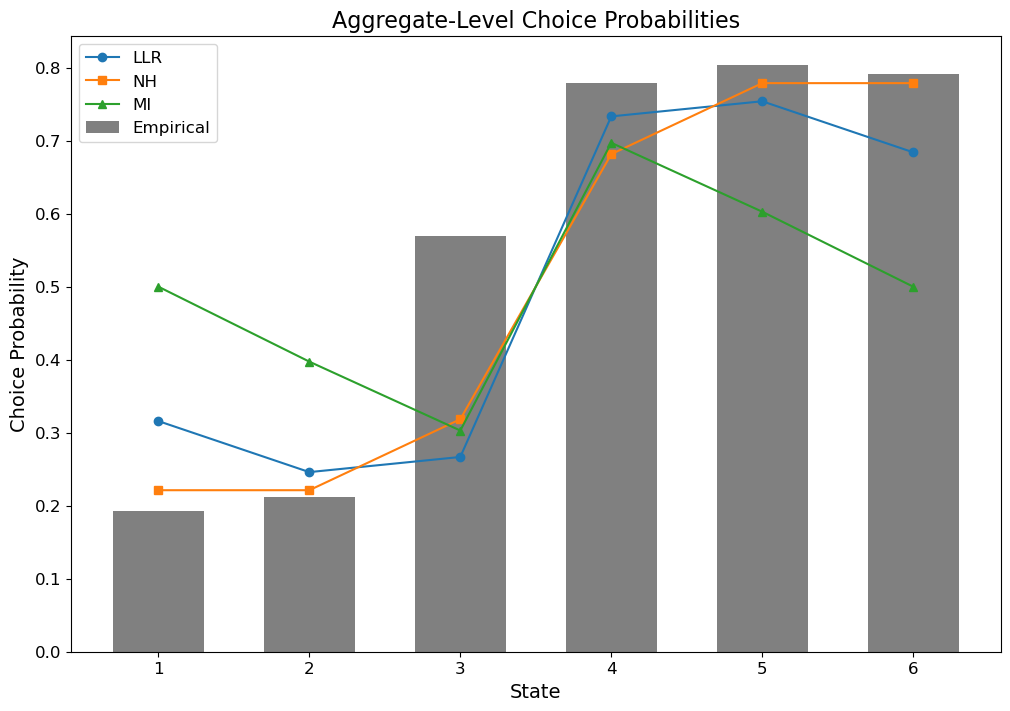

In [17]:
# Prepare data for plotting
df_plot = pd.DataFrame({
    'State': np.arange(1, N + 1),
    'Empirical': data_agg['mean_e'].values,
    'LLR': probabilities_agg['LLR'],
    'NH': probabilities_agg['NH'],
    'MI': probabilities_agg['MI']
})

# Convert 'State' to integer type if not already
df_plot['State'] = df_plot['State'].astype(int)

fig, ax = plt.subplots(figsize=(12, 8))

x = df_plot['State']
empirical = df_plot['Empirical']

# Plot bars
ax.bar(x, empirical, color='gray', label='Empirical', width=0.6)

llr = df_plot['LLR']
nh = df_plot['NH']
mi = df_plot['MI']

# Plot lines
ax.plot(x, llr, marker='o', label='LLR')
ax.plot(x, nh, marker='s', label='NH')
ax.plot(x, mi, marker='^', label='MI')

ax.set_xlabel('State', fontsize=14)
ax.set_ylabel('Choice Probability', fontsize=14)
ax.set_title('Aggregate-Level Choice Probabilities', fontsize=16)
ax.legend(title='', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.show()

In [18]:
# Define asymmetric reward structure
r_matrix = np.array([
    [0, -0.5, -1, 1, 0.5, 0],
    [0, -5, -10, 10, 5, 0],
    [0, -0.5, -1, 5, 0.5, 0],
    [0, -5, -1, 1, 0.5, 0],
    [0, -0.5, -5, 10, 0.5, 0],
    [0, -0.5, -10, 5, 0.5, 0]
])

# Exclude certain participants
rows_to_exclude = [0, 4, 11, 31]  # Adjusted for zero-based indexing
included_indices = [i for i in include_subj if i not in rows_to_exclude]
n_participants = len(included_indices)


In [19]:
# Initialize dictionaries to store probabilities
asymmetric_probs = {'LLR': [], 'NH': [], 'MI': []}

for idx in included_indices:
    participant_probs = {'LLR': [], 'NH': [], 'MI': []}
    for rewards in r_matrix:
        for model_name in ['LLR', 'NH', 'MI']:
            est_param = par_estimates[model_name][idx]
            def obj_fn(prob):
                return -np.sum(rewards * prob) / N + cost_functions[model_name](prob, est_param)
            res = opt.minimize(obj_fn, x0=initial_guess, bounds=con_bounds, method='L-BFGS-B')
            prob_opt = res.x
            participant_probs[model_name].append(prob_opt)
    for model_name in ['LLR', 'NH', 'MI']:
        asymmetric_probs[model_name].append(participant_probs[model_name])


In [20]:
# Function to average matrices
def average_matrices(prob_list):
    prob_array = np.array(prob_list)  # Shape: (num_participants, num_reward_structures, N)
    return np.mean(prob_array, axis=0)  # Average over participants

# Calculate average probabilities
average_probs = {}
for model_name in ['LLR', 'NH', 'MI']:
    average_probs[model_name] = average_matrices(asymmetric_probs[model_name])


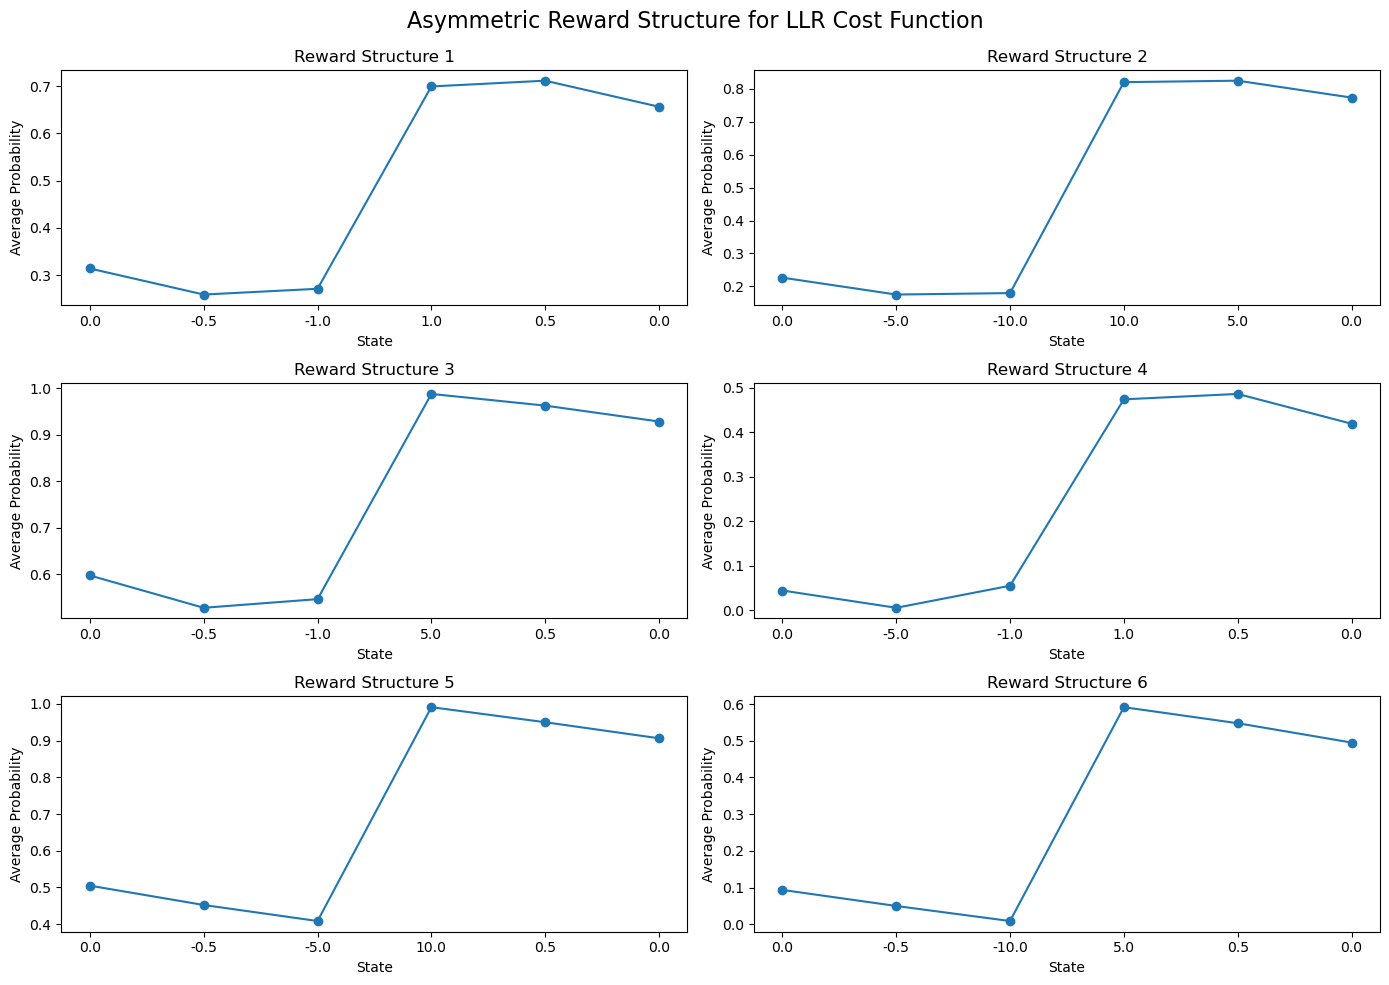

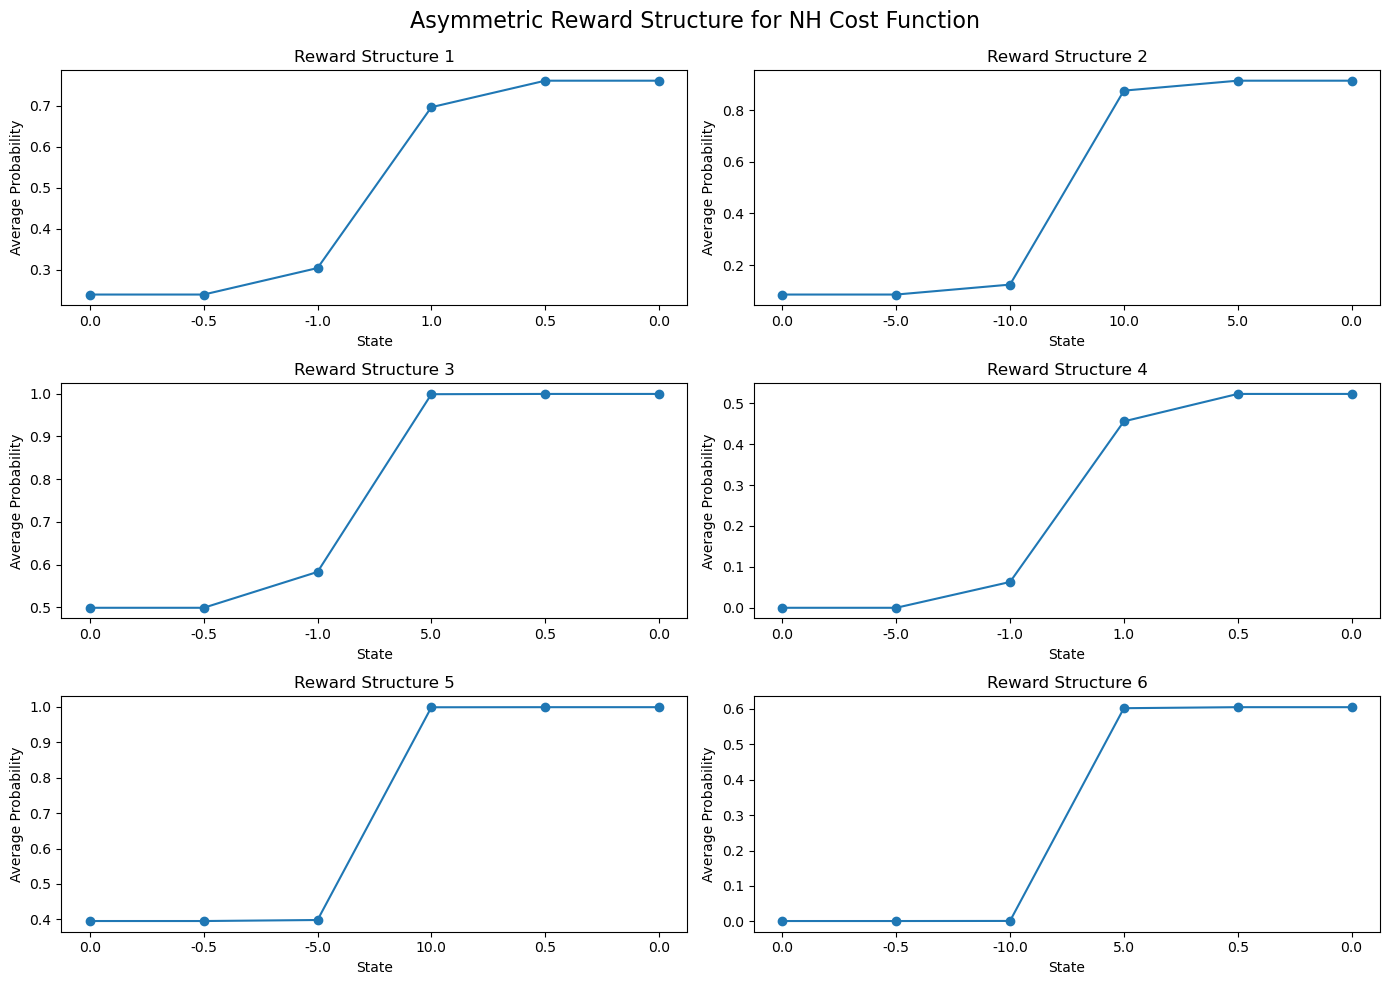

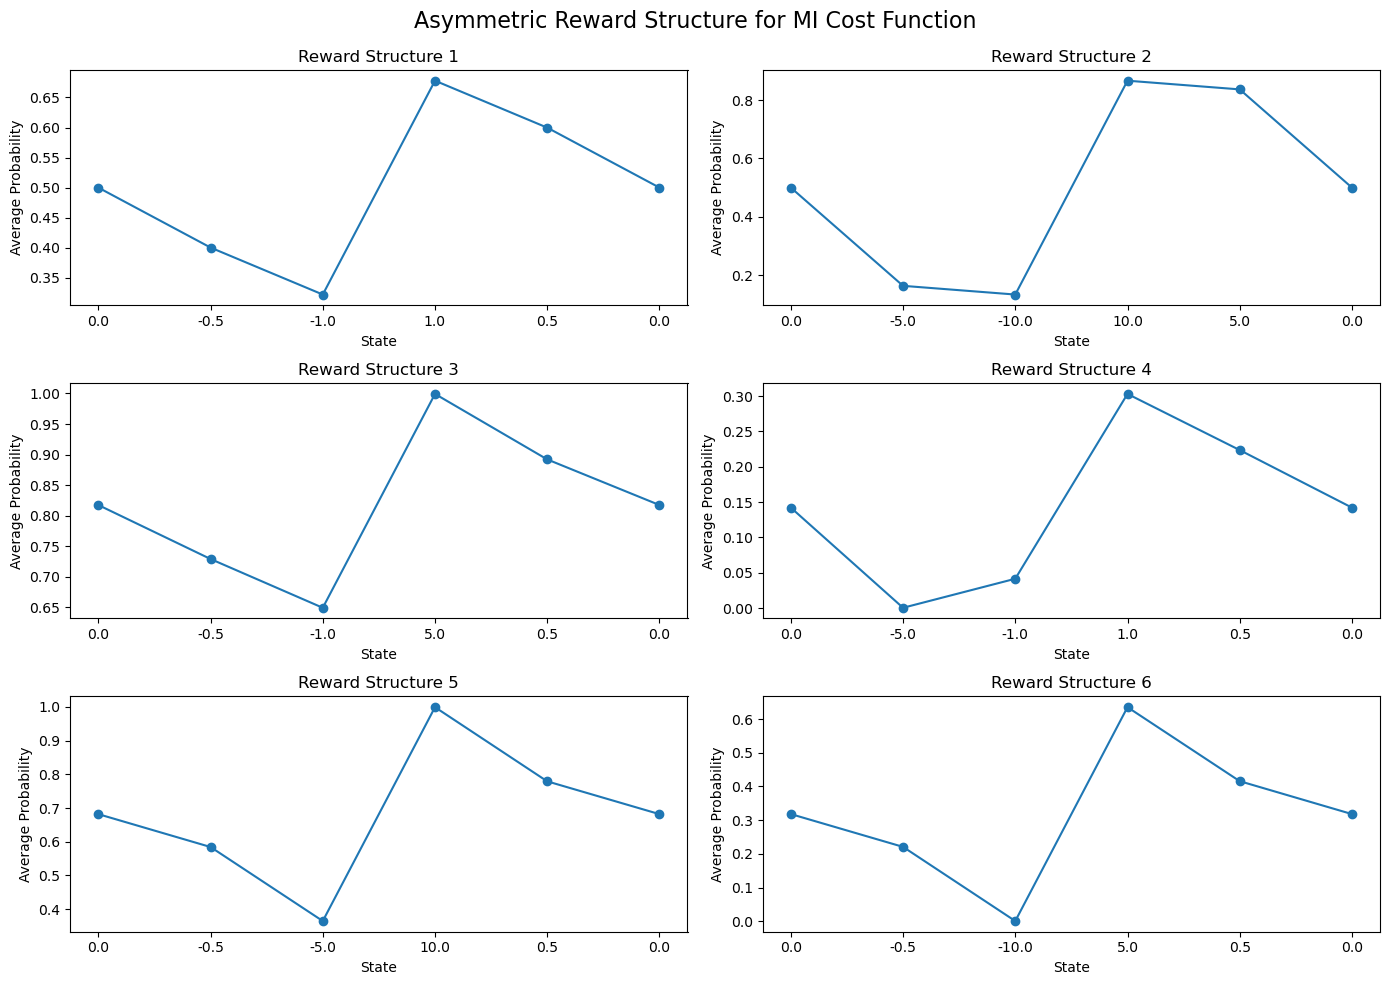

In [21]:
# Function to plot asymmetric reward structures
def plot_asymmetric_reward(avg_matrix, title):
    fig, axs = plt.subplots(3, 2, figsize=(14, 10))
    axs = axs.flatten()
    for i in range(len(r_matrix)):
        axs[i].plot(np.arange(1, N + 1), avg_matrix[i, :], marker='o')
        axs[i].set_title(f'Reward Structure {i + 1}')
        axs[i].set_xlabel('State')
        axs[i].set_ylabel('Average Probability')
        axs[i].set_xticks(np.arange(1, N + 1))
        axs[i].set_xticklabels(r_matrix[i, :])
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# Plot for each model
for model_name in ['LLR', 'NH', 'MI']:
    avg_matrix = average_probs[model_name]
    plot_title = f'Asymmetric Reward Structure for {model_name} Cost Function'
    plot_asymmetric_reward(avg_matrix, plot_title)
